# Data-Driven Demand Planning and Adaptive EOQ Model for Inventory Optimization

This notebook presents a data science project that extends the classical Economic Order Quantity (EOQ) inventory model by integrating demand forecasting.

The project combines:
- retail transaction data,
- UK public holiday data,
- data analysis,
- demand forecasting,
- EOQ-based inventory optimization,
- inventory simulation,
- business interpretation.

## 1. Business Problem Formulation

Inventory control is a key challenge in retail and supply chain management.

The classical EOQ model assumes that demand is constant and known in advance. In practice, this is rarely the case, as demand in retail changes over time and is influenced by factors such as seasonality, holidays, and customer behavior.

In this project, the EOQ model is extended by incorporating demand forecasting. Historical sales data, along with calendar and lag-based features, is used to train a Random Forest regression model.

Unlike the standard EOQ approach, which relies on a fixed historical demand value, the adaptive EOQ model uses predicted demand as input, making it more flexible and better suited to real-world conditions.

This approach allows for more realistic and data-driven inventory decisions.

### Main research question

How can demand forecasting help classical EOQ-based inventory planning?

### Project objectives

- Analyze historical retail sales data.
- Combine sales data with UK holiday data.
- Explore demand variability over time.
- Build and evaluate demand forecasting models.
- Calculate static EOQ and adaptive EOQ.
- Simulate inventory behavior under both approaches.
- Interpret the business impact of data-driven inventory planning.

## 2. Data Sources and Availability

This project uses two independent data sources:

1. **Online Retail Dataset**  
   A transactional retail dataset containing invoice-level sales data, product identifiers, quantities, prices, customers, and countries. Due to GitHub file size limitations, the full dataset is not included in the repository. It is used locally for analysis.

2. **UK Holidays Dataset**  
   A calendar dataset containing UK public holidays. It is included in the repository and used as an external factor that may influence demand.

Expected local file paths:

```text
data/raw/online_retail.csv
data/raw/UK_holiday.csv
```

## 3. Imports and Configuration

In [1]:
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", None)

## 4. Load the Data
The notebook expects the two datasets to be located in the data/raw/ folder.
If the sales dataset is not included in GitHub due to size limitations, it should still be placed locally in the same folder structure.

In [2]:
sales_path = "../data/raw/online_retail.csv"
holidays_path = "../data/raw/UK_holiday.csv"
sales = pd.read_csv(sales_path, encoding="ISO-8859-1")
holidays = pd.read_csv(holidays_path, encoding="ISO-8859-1")

display(sales.head())
display(holidays.head())

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


,title,date,notes,bunting
0,New Yearâs Day,2018-01-01,NaN,True
1,Good Friday,2018-03-30,NaN,False
2,Easter Monday,2018-04-02,NaN,True
3,Early May bank holiday,2018-05-07,NaN,True
4,Spring bank holiday,2018-05-28,NaN,True


## 5. Initial Data Understanding

Before cleaning the data, we inspect its structure, missing values, and date ranges.

In [3]:
print("Sales shape:", sales.shape)
print("Holidays shape:", holidays.shape)

display(sales.info())
display(holidays.info())

Sales shape: (541909, 8)
Holidays shape: (67, 4)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


None

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 67 entries, 0 to 66
Data columns (total 4 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   title    67 non-null     object
 1   date     67 non-null     object
 2   notes    6 non-null      object
 3   bunting  67 non-null     bool  
dtypes: bool(1), object(3)
memory usage: 1.8+ KB


None

In [4]:
print("Sales columns:")
print(sales.columns.tolist())

print("Holiday columns:")
print(holidays.columns.tolist())

Sales columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']
Holiday columns:
['title', 'date', 'notes', 'bunting']


In [5]:
sales["InvoiceDate"] = pd.to_datetime(sales["InvoiceDate"], errors="coerce")
holidays["date"] = pd.to_datetime(holidays["date"], errors="coerce")

print("Sales date range:", sales["InvoiceDate"].min(), "to", sales["InvoiceDate"].max())
print("Holiday date range:", holidays["date"].min(), "to", holidays["date"].max())

Sales date range: 2010-12-01 08:26:00 to 2011-12-09 12:50:00
Holiday date range: 2018-01-01 00:00:00 to 2025-12-26 00:00:00


Country
United Kingdom    495478
Germany             9495
France              8557
EIRE                8196
Spain               2533
Netherlands         2371
Belgium             2069
Switzerland         2002
Portugal            1519
Australia           1259
Name: count, dtype: int64

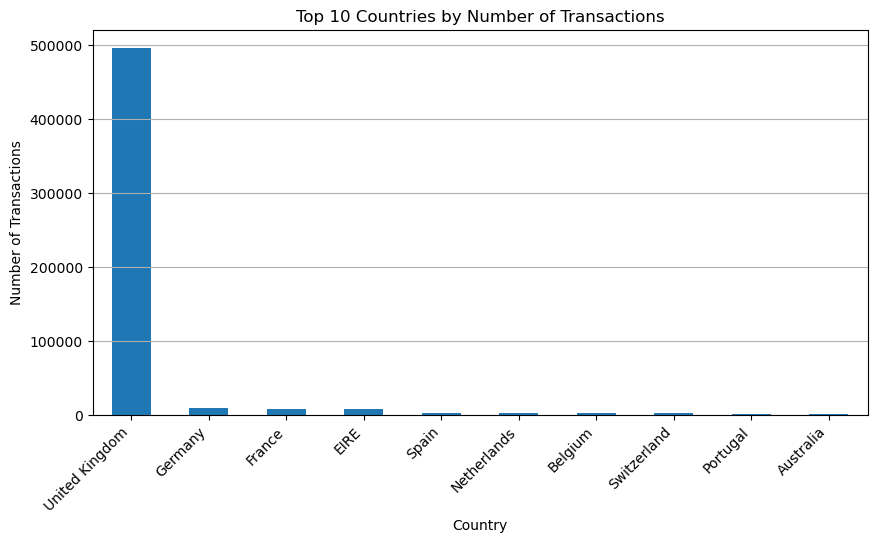

In [6]:
country_distribution = sales["Country"].value_counts()

display(country_distribution.head(10))

plt.figure(figsize=(10, 5))
country_distribution.head(10).plot(kind="bar")
plt.title("Top 10 Countries by Number of Transactions")
plt.xlabel("Country")
plt.ylabel("Number of Transactions")
plt.xticks(rotation=45, ha="right")
plt.grid(axis="y")
plt.show()

### Interpretation
The Online Retail data set is heavilyUK biased.
Since the external calendar dataset includes UK holidays the analysis is restricted to demand patterns related to the UK. This ensures the data sources are consistent, and the original country information is not altered.

## 6. Data Cleaning

The sales data is cleaned by removing:
- missing invoice dates,
- missing quantities or prices,
- negative or zero quantities,
- negative or zero unit prices.

Negative quantities usually represent returns or cancellations. Since the project focuses on demand forecasting, only positive sales transactions are used.

In [7]:
sales_clean = sales.copy()

sales_clean = sales_clean.dropna(subset=["InvoiceDate", "Quantity", "UnitPrice", "StockCode"])
sales_clean = sales_clean[sales_clean["Quantity"] > 0]
sales_clean = sales_clean[sales_clean["UnitPrice"] > 0]

sales_clean["revenue"] = sales_clean["Quantity"] * sales_clean["UnitPrice"]

print("Cleaned sales shape:", sales_clean.shape)
sales_clean.head()

Cleaned sales shape: (530104, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom,20.34


## 7. Date Alignment with the Holiday Dataset
The retail sales dataset contains the years running from 2010 to 2011, while the UK holiday dataset comprises a number of years out in the future.
In order to combine these two sources, sales dates are moved forward to align with the holiday calendar.

This conversion maintains the original pattern of demand, while letting the project illustrate how data can be consolidated against an external calendar source.

The shift value will be calculated automatically based on the earliest year in the holiday dataset and the first year in the sales dataset.

In [8]:
sales_min_year = sales_clean["InvoiceDate"].dt.year.min()
holiday_min_year = holidays["date"].dt.year.min()

year_shift = holiday_min_year - sales_min_year

print("Sales minimum year:", sales_min_year)
print("Holiday minimum year:", holiday_min_year)
print("Year shift applied:", year_shift)

sales_clean["InvoiceDate_original"] = sales_clean["InvoiceDate"]
sales_clean["InvoiceDate"] = sales_clean["InvoiceDate"] + pd.DateOffset(years=int(year_shift))
sales_clean["date"] = sales_clean["InvoiceDate"].dt.date

print("Shifted sales date range:", sales_clean["InvoiceDate"].min(), "to", sales_clean["InvoiceDate"].max())

Sales minimum year: 2010
Holiday minimum year: 2018
Year shift applied: 8
Shifted sales date range: 2018-12-01 08:26:00 to 2019-12-09 12:50:00


## 8. Daily Demand Aggregation

The transaction-level data is aggregated to daily level.  
This creates a time series of daily demand, which is suitable for forecasting and inventory optimization.

In [9]:
daily_demand = (
    sales_clean
    .groupby("date")
    .agg(
        quantity_sold=("Quantity", "sum"),
        revenue=("revenue", "sum"),
        unique_products=("StockCode", "nunique"),
        unique_customers=("CustomerID", "nunique")
    )
    .reset_index()
)

daily_demand["date"] = pd.to_datetime(daily_demand["date"])
daily_demand.head().style.format({
    "date": lambda x: x.strftime("%Y-%m-%d"),
    "quantity_sold": lambda x: f"{x:,.0f}".replace(",", " "),
    "revenue":  lambda x: f"{x:,.0f}".replace(",", " "),
    "unique_products":  lambda x: f"{x:,.0f}".replace(",", " "),
    "unique_customers":  lambda x: f"{x:,.0f}".replace(",", " "),
})

,date,quantity_sold,revenue,unique_products,unique_customers
0,2018-12-01,26 919,58 961,1 340,95
1,2018-12-02,31 329,47 748,923,99
2,2018-12-03,16 199,46 944,1 133,50
3,2018-12-05,16 450,31 775,1 142,75
4,2018-12-06,21 795,54 830,1 471,82


In [10]:
daily_demand = (
    sales_clean
    .groupby("date")
    .agg(
        quantity_sold=("Quantity", "sum"),
        revenue=("revenue", "sum"),
        unique_products=("StockCode", "nunique"),
        unique_customers=("CustomerID", "nunique")
    )
    .reset_index()
)

daily_demand["date"] = pd.to_datetime(daily_demand["date"])

daily_demand.head().style.format({
    "date": lambda x: x.strftime("%Y-%m-%d"),
    "quantity_sold": lambda x: f"{x:,.0f}".replace(",", " "),
    "revenue": lambda x: f"{x:,.2f}".replace(",", " "),
    "unique_products": lambda x: f"{x:,.0f}".replace(",", " "),
    "unique_customers": lambda x: f"{x:,.0f}".replace(",", " "),
    })

,date,quantity_sold,revenue,unique_products,unique_customers
0,2018-12-01,26 919,58 960.79,1 340,95
1,2018-12-02,31 329,47 748.38,923,99
2,2018-12-03,16 199,46 943.71,1 133,50
3,2018-12-05,16 450,31 774.95,1 142,75
4,2018-12-06,21 795,54 830.46,1 471,82


## 9. Holiday Data Preparation and Merge

The holiday dataset is converted into a simple calendar feature: `is_holiday`.

Each holiday date receives a value of `1`. All other dates receive a value of `0` after merging.

In [11]:
holidays_clean = holidays.copy()

holidays_clean["date"] = pd.to_datetime(holidays_clean["date"], errors="coerce")
holidays_clean = holidays_clean.dropna(subset=["date"])

holidays_clean["is_holiday"] = 1

# Keep useful columns if they exist
holiday_columns = ["date", "is_holiday"]
if "title" in holidays_clean.columns:
    holiday_columns.append("title")

holidays_clean = holidays_clean[holiday_columns].drop_duplicates(subset=["date"])

holidays_clean.head()

,date,is_holiday,title
0,2018-01-01,1,New Yearâs Day
1,2018-03-30,1,Good Friday
2,2018-04-02,1,Easter Monday
3,2018-05-07,1,Early May bank holiday
4,2018-05-28,1,Spring bank holiday


In [12]:
daily_demand = daily_demand.merge(
    holidays_clean[["date", "is_holiday"]],
    on="date",
    how="left"
)

daily_demand["is_holiday"] = daily_demand["is_holiday"].fillna(0).astype(int)

daily_demand.head().style.format({
    "date": lambda x: x.strftime("%Y-%m-%d"),
    "quantity_sold": lambda x: f"{x:,.0f}".replace(",", " "),
    "revenue": lambda x: f"{x:,.2f}".replace(",", " "),
    "unique_products": lambda x: f"{x:,.0f}".replace(",", " "),
    "unique_customers": lambda x: f"{x:,.0f}".replace(",", " "),
    })

,date,quantity_sold,revenue,unique_products,unique_customers,is_holiday
0,2018-12-01,26 919,58 960.79,1 340,95,0
1,2018-12-02,31 329,47 748.38,923,99,0
2,2018-12-03,16 199,46 943.71,1 133,50,0
3,2018-12-05,16 450,31 774.95,1 142,75,0
4,2018-12-06,21 795,54 830.46,1 471,82,0


In [13]:
print("Number of holiday days in the merged demand data:")
print(daily_demand["is_holiday"].value_counts())

Number of holiday days in the merged demand data:
is_holiday
0    301
1      4
Name: count, dtype: int64


## 10. Feature Engineering

Calendar-based features are created to help the forecasting model capture recurring patterns in demand.

In addition, lag features and rolling averages are added so that the model can use recent demand history. This is important because demand forecasting is a time-dependent problem, and previous demand values often contain useful information about future demand.


In [14]:
daily_demand = daily_demand.sort_values("date").reset_index(drop=True)

daily_demand["day_of_week"] = daily_demand["date"].dt.dayofweek
daily_demand["month"] = daily_demand["date"].dt.month
daily_demand["week_of_year"] = daily_demand["date"].dt.isocalendar().week.astype(int)
daily_demand["is_weekend"] = daily_demand["day_of_week"].isin([5, 6]).astype(int)

# Lag features: demand from previous periods
# These features help the model capture temporal dependency in demand.
daily_demand["lag_1"] = daily_demand["quantity_sold"].shift(1)
daily_demand["lag_7"] = daily_demand["quantity_sold"].shift(7)

# Rolling average based only on past values.
# shift(1) is used to avoid using the current day's demand when predicting that same day.
daily_demand["rolling_mean_7"] = daily_demand["quantity_sold"].shift(1).rolling(window=7).mean()

# Remove the first rows where lag and rolling features are not available.
daily_demand = daily_demand.dropna().reset_index(drop=True)

daily_demand.head().style.format({
    "date": lambda x: x.strftime("%Y-%m-%d"),
    "quantity_sold": lambda x: f"{x:,.0f}".replace(",", " "),
    "revenue": lambda x: f"{x:,.2f}".replace(",", " "),
    "unique_products": lambda x: f"{x:,.0f}".replace(",", " "),
    "unique_customers": lambda x: f"{x:,.0f}".replace(",", " "),
    "lag_1": lambda x: f"{x:,.0f}".replace(",", " "),
    "lag_7": lambda x: f"{x:,.0f}".replace(",", " "),
    "rolling_mean_7": lambda x: f"{x:,.2f}".replace(",", " "),
    })


,date,quantity_sold,revenue,unique_products,unique_customers,is_holiday,day_of_week,month,week_of_year,is_weekend,lag_1,lag_7,rolling_mean_7
0,2018-12-09,19 930,53 586.18,1 258,90,0,6,12,49,1,23 117,26 919,23 004.14
1,2018-12-10,21 097,59 182.92,1 264,53,0,0,12,50,0,19 930,31 329,22 005.71
2,2018-12-12,10 603,17 329.07,800,42,0,2,12,50,0,21 097,16 199,20 544.00
3,2018-12-13,17 727,38 006.71,1 169,59,0,3,12,50,0,10 603,16 450,19 744.57
4,2018-12-14,20 284,45 254.73,1 010,73,0,4,12,50,0,17 727,21 795,19 927.00


### Lag Feature Interpretation

The lag features represent demand from previous periods. For example, `lag_1` is the demand from the previous day, while `lag_7` is the demand from one week earlier.

The `rolling_mean_7` feature smooths short-term fluctuations by using the average demand from the previous seven days. These features give the model a simple form of memory, which is especially useful for time-series forecasting.


## 11. Exploratory Data Analysis

The purpose of the exploratory analysis is to determine if the demand is stable or fluctuating over time.
If demand is very volatile, the classical EOQ assumption of constant demand is less realistic.

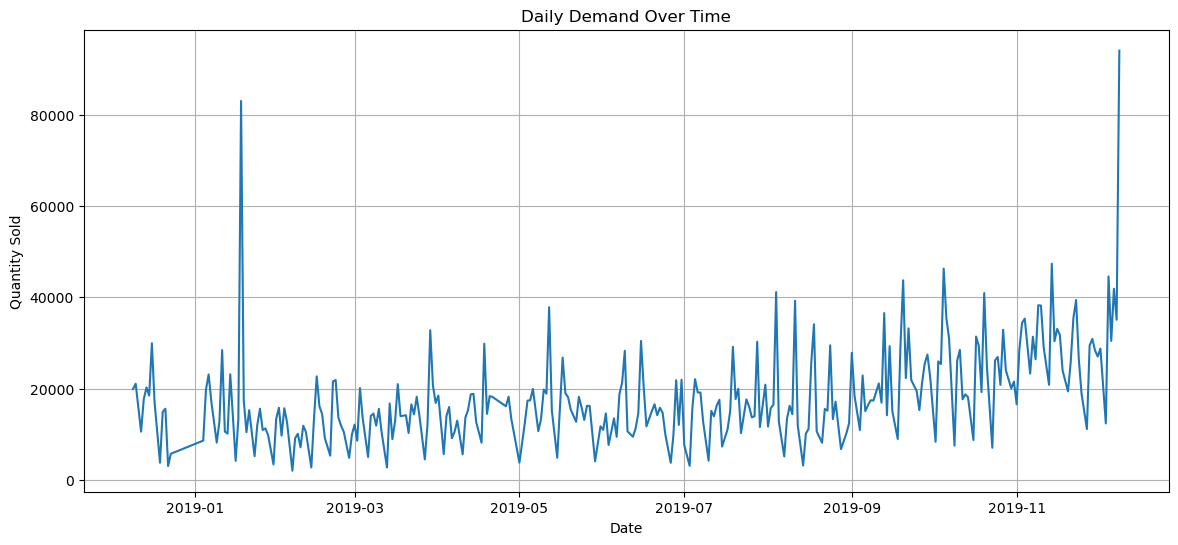

In [15]:
plt.figure(figsize=(14, 6))
plt.plot(daily_demand["date"], daily_demand["quantity_sold"])
plt.title("Daily Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.grid(True)
plt.show()

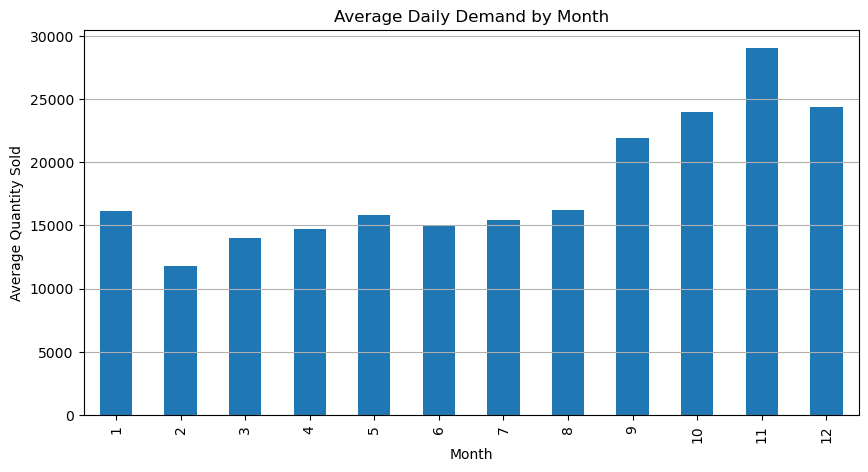

In [16]:
monthly_demand = daily_demand.groupby("month")["quantity_sold"].mean()

plt.figure(figsize=(10, 5))
monthly_demand.plot(kind="bar")
plt.title("Average Daily Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Quantity Sold")
plt.grid(axis="y")
plt.show()

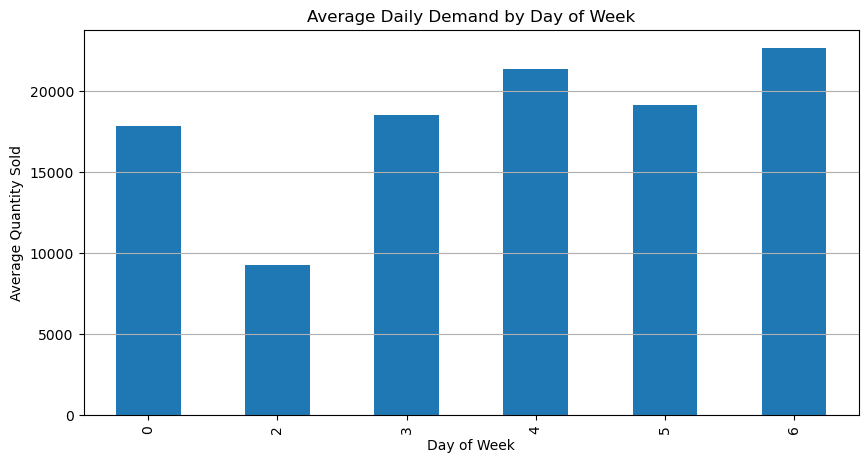

In [17]:
weekday_demand = daily_demand.groupby("day_of_week")["quantity_sold"].mean()

plt.figure(figsize=(10, 5))
weekday_demand.plot(kind="bar")
plt.title("Average Daily Demand by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Average Quantity Sold")
plt.grid(axis="y")
plt.show()

In [18]:
holiday_effect = daily_demand.groupby("is_holiday")["quantity_sold"].agg(["mean", "median", "count"])
holiday_effect.style.format({
     "mean": lambda x: f"{x:,.2f}".replace(",", " "),
     "median": lambda x: f"{x:,.2f}".replace(",", " "),
    })

,mean,median,count
is_holiday,,,
0,18 229.76,15 966.00,294
1,16 949.75,16 685.00,4


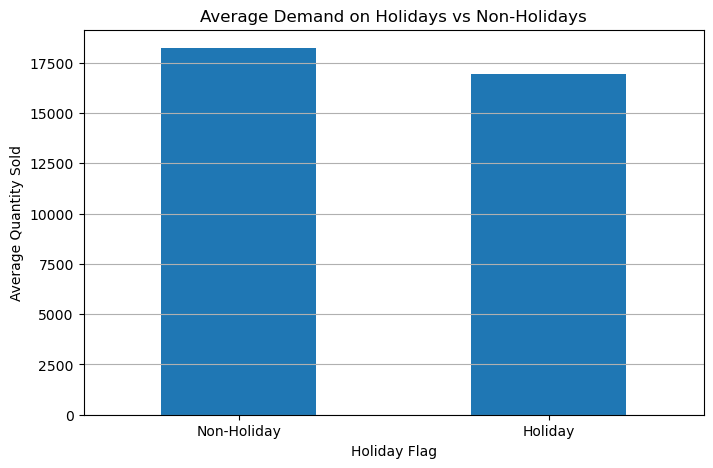

In [19]:
holiday_effect["mean"].plot(kind="bar", figsize=(8, 5))
plt.title("Average Demand on Holidays vs Non-Holidays")
plt.xlabel("Holiday Flag")
plt.ylabel("Average Quantity Sold")
plt.xticks([0, 1], ["Non-Holiday", "Holiday"], rotation=0)
plt.grid(axis="y")
plt.show()

### EDA Interpretation
The preliminary analysis shows that the demand varies with time.
Dates, months and days of the week all exhibit fluctuations. Holiday periods are also introduced as an exogenous signal.
These results are backing the main thesis of the project: a static EOQ model might be too simplistic for the retail demand planning, while a data driven adaptative model is able to better adapt to changes in demand.

## 12. Demand Forecasting

A time-based train-test split is used because demand forecasting is a temporal problem.  
The model is trained on earlier observations and evaluated on later observations.

Two forecasting approaches are compared:

1. **Naive baseline model**  
   Uses the last observed training demand as the forecast.

2. **Random Forest regression model**  
   Uses calendar-based, holiday-related, lag, and rolling-average features to estimate demand.

The lag and rolling features are included to help the model learn from recent demand patterns instead of relying only on calendar information.


In [20]:
daily_demand = daily_demand.sort_values("date").reset_index(drop=True)

features = [
    "day_of_week",
    "month",
    "week_of_year",
    "is_weekend",
    "is_holiday",
    "lag_1",
    "lag_7",
    "rolling_mean_7"
]

target = "quantity_sold"

split_index = int(len(daily_demand) * 0.8)

train = daily_demand.iloc[:split_index].copy()
test = daily_demand.iloc[split_index:].copy()

X_train = train[features]
y_train = train[target]

X_test = test[features]
y_test = test[target]

print("Train period:", train["date"].min(), "to", train["date"].max())
print("Test period:", test["date"].min(), "to", test["date"].max())
print("Features used:", features)


Train period: 2018-12-09 00:00:00 to 2019-09-30 00:00:00
Test period: 2019-10-02 00:00:00 to 2019-12-09 00:00:00
Features used: ['day_of_week', 'month', 'week_of_year', 'is_weekend', 'is_holiday', 'lag_1', 'lag_7', 'rolling_mean_7']


### 12.1 Naive Baseline Model

In [21]:
test["naive_forecast"] = train[target].iloc[-1]

mae_baseline = mean_absolute_error(y_test, test["naive_forecast"])
rmse_baseline = np.sqrt(mean_squared_error(y_test, test["naive_forecast"]))

print("Naive MAE:", mae_baseline)
print("Naive RMSE:", rmse_baseline)

Naive MAE: 9510.733333333334
Naive RMSE: 13791.507131806395


### 12.2 Random Forest Forecasting Model

In [22]:
model = RandomForestRegressor(
    n_estimators=200,
    max_depth=8,
    random_state=42
)

model.fit(X_train, y_train)

test["forecast"] = model.predict(X_test)

mae_model = mean_absolute_error(y_test, test["forecast"])
rmse_model = np.sqrt(mean_squared_error(y_test, test["forecast"]))

print("Random Forest MAE:", mae_model)
print("Random Forest RMSE:", rmse_model)

Random Forest MAE: 9213.882109892766
Random Forest RMSE: 13661.47665575203


### 12.3 Model Comparison

In [23]:
model_comparison = pd.DataFrame({
    "Model": ["Naive Baseline", "Random Forest"],
    "MAE": [mae_baseline, mae_model],
    "RMSE": [rmse_baseline, rmse_model]
})

model_comparison

,Model,MAE,RMSE
0,Naive Baseline,9510.733333,13791.507132
1,Random Forest,9213.882110,13661.476656


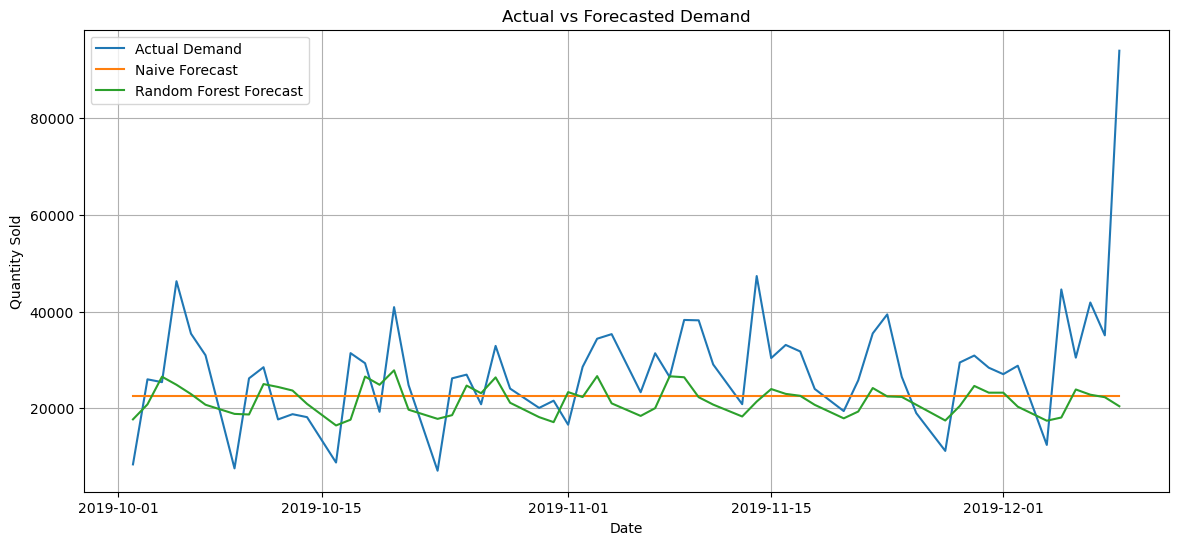

In [24]:
plt.figure(figsize=(14, 6))
plt.plot(test["date"], y_test.values, label="Actual Demand")
plt.plot(test["date"], test["naive_forecast"], label="Naive Forecast")
plt.plot(test["date"], test["forecast"], label="Random Forest Forecast")
plt.title("Actual vs Forecasted Demand")
plt.xlabel("Date")
plt.ylabel("Quantity Sold")
plt.legend()
plt.grid(True)
plt.show()

### Forecasting Interpretation

The forecasting model is evaluated against a naive baseline using MAE and RMSE. The goal is not only to predict demand, but also to create a more dynamic input for the EOQ calculation.

The Random Forest model now uses both calendar variables and historical demand information through lag and rolling-average features. This makes the forecasting setup more appropriate for time-series data, because the model can learn from recent demand behavior instead of relying only on the date-related variables.

If the model still does not outperform the naive baseline, this should be interpreted as an important limitation rather than a failure of the full project. It shows that demand forecasting is difficult and that simple baselines can be strong benchmarks.


### 12.4 Feature Importance

Feature importance helps explain which variables contributed most to the Random Forest forecast.

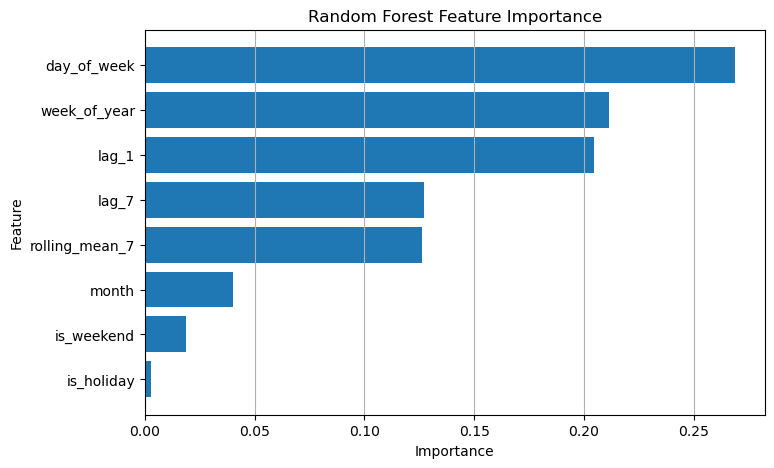

,Feature,Importance
0,day_of_week,0.268819
2,week_of_year,0.211507
5,lag_1,0.204629
6,lag_7,0.126960
7,rolling_mean_7,0.126156
1,month,0.040351
3,is_weekend,0.018609
4,is_holiday,0.002969


In [25]:
feature_importance = pd.DataFrame({
    "Feature": features,
    "Importance": model.feature_importances_
}).sort_values("Importance", ascending=True)

plt.figure(figsize=(8, 5))
plt.barh(feature_importance["Feature"], feature_importance["Importance"])
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.grid(axis="x")
plt.show()

feature_importance.sort_values("Importance", ascending=False)

## 13. EOQ and Adaptive EOQ Model

The classical Economic Order Quantity model estimates the optimal order quantity by balancing ordering costs and holding costs.

The classical formula is:

$$
EOQ = \sqrt{\frac{2DS}{H}}
$$
where:

- $D$ = annual demand,
- $S$ = ordering cost per order,
- $H$ = holding cost per unit per year.

In the adaptive version, demand is not fixed. Instead, forecasted demand is used:

$$
EOQ_t = \sqrt{\frac{2D_tS}{H}}
$$

where $D_t$ is the forecasted demand for time period $t$.

In [26]:
# Assumed cost parameters for demonstration
ordering_cost = 50
holding_cost = 2

annual_demand = daily_demand["quantity_sold"].mean() * 365

static_eoq = np.sqrt((2 * annual_demand * ordering_cost) / holding_cost)

print("Annual demand estimate:", annual_demand)
print("Static EOQ:", static_eoq)

Annual demand estimate: 6647589.4463087255
Static EOQ: 18231.27730893906


In [27]:
# Dynamic EOQ based on forecasted demand
# The forecast is daily, so it is annualized by multiplying by 365.
test["forecast_annualized"] = test["forecast"] * 365

test["dynamic_eoq"] = np.sqrt(
    (2 * test["forecast_annualized"] * ordering_cost) / holding_cost
)

test[["date", "forecast", "forecast_annualized", "dynamic_eoq"]].head().style.format({
     "date": lambda x: x.strftime("%Y-%m-%d"),
     "forecast": lambda x: f"{x:,.2f}".replace(",", " "),
     "forecast_annualized": lambda x: f"{x:,.2f}".replace(",", " "),
     "dynamic_eoq": lambda x: f"{x:,.2f}".replace(",", " "),
    })

,date,forecast,forecast_annualized,dynamic_eoq
238,2019-10-02,17 700.10,6 460 538.16,17 972.95
239,2019-10-03,20 807.23,7 594 639.88,19 486.71
240,2019-10-04,26 524.47,9 681 432.80,22 001.63
241,2019-10-05,24 858.21,9 073 247.95,21 299.35
242,2019-10-06,22 934.69,8 371 162.91,20 458.69


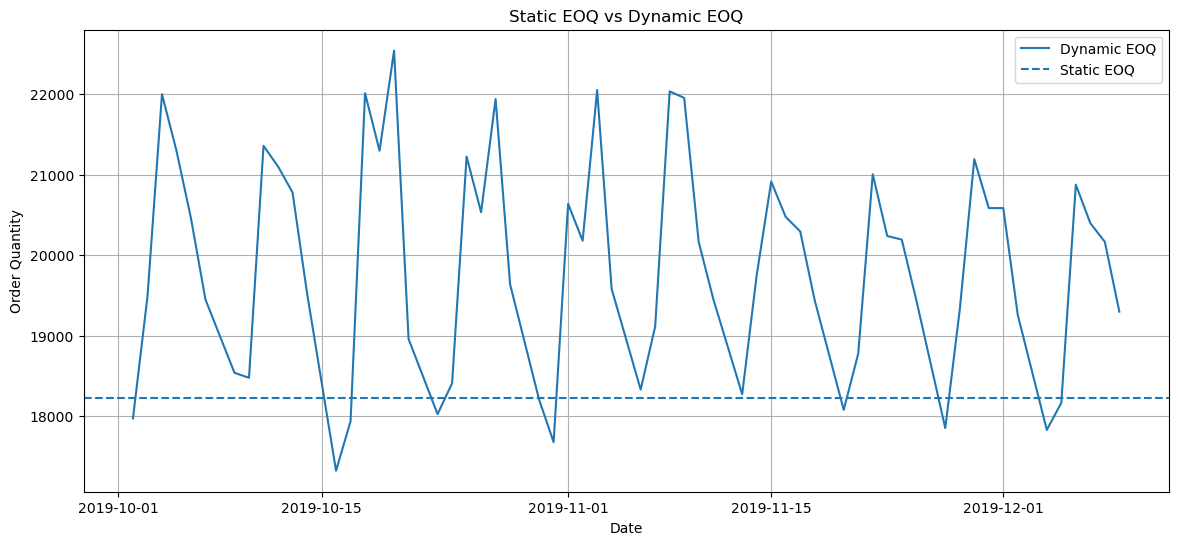

In [28]:
plt.figure(figsize=(14, 6))
plt.plot(test["date"], test["dynamic_eoq"], label="Dynamic EOQ")
plt.axhline(static_eoq, linestyle="--", label="Static EOQ")
plt.title("Static EOQ vs Dynamic EOQ")
plt.xlabel("Date")
plt.ylabel("Order Quantity")
plt.legend()
plt.grid(True)
plt.show()

### EOQ Interpretation

Regarding the classicised EOQ it only requires one fixed demand estimate.
The dynamic EOQ is calculated from predicted demand and so changes over time.
This renders the adaptive model better tailored for demand planning in an environment of sales that vary over time.

## 14. Reorder Point and Safety Stock

The Reorder Point (ROP) estimates when a new order should be placed.

A simplified formula is:

$$
ROP = dL + Z\sigma_d\sqrt{L}
$$
where:

- $d$ = average daily demand,
- $L$ = lead time in days,
- $Z$ = service level factor,
- $sigma_d$ = standard deviation of daily demand.

In [29]:
lead_time_days = 7
service_level_z = 1.65  # approximately 95% service level

demand_std = train["quantity_sold"].std()

test["reorder_point"] = (
    test["forecast"] * lead_time_days
    + service_level_z * demand_std * np.sqrt(lead_time_days)
)

test[["date", "forecast", "dynamic_eoq", "reorder_point"]].head().style.format({
     "date": lambda x: x.strftime("%Y-%m-%d"),
     "forecast": lambda x: f"{x:,.2f}".replace(",", " "),
     "dynamic_eoq": lambda x: f"{x:,.2f}".replace(",", " "),
     "reorder_point": lambda x: f"{x:,.2f}".replace(",", " "),
    })

,date,forecast,dynamic_eoq,reorder_point
238,2019-10-02,17 700.10,17 972.95,160 941.96
239,2019-10-03,20 807.23,19 486.71,182 691.85
240,2019-10-04,26 524.47,22 001.63,222 712.54
241,2019-10-05,24 858.21,21 299.35,211 048.72
242,2019-10-06,22 934.69,20 458.69,197 584.08


## 15. Inventory Simulation

Simplified inventory simulation is employed to evaluate the static EOQ and adaptive EOQ policies.
The simulation uses real test period demand and compares:
- inventory levels,
- holding costs,
- stockout days,
- stockout costs,
- total cost.
  
This is a simplified model, based on purposes of analytical comparison rather than an actual warehouse system.

In [34]:
simulation = test.copy().reset_index(drop=True)

stockout_cost_per_day = 500
initial_inventory = static_eoq

static_inventory = []
dynamic_inventory = []

current_static_inventory = initial_inventory
current_dynamic_inventory = initial_inventory

for _, row in simulation.iterrows():
    demand = row["quantity_sold"]

    # Static EOQ strategy
    current_static_inventory -= demand
    if current_static_inventory <= row["reorder_point"]:
        current_static_inventory += static_eoq

    # Dynamic EOQ strategy
    current_dynamic_inventory -= demand
    if current_dynamic_inventory <= row["reorder_point"]:
        current_dynamic_inventory += row["dynamic_eoq"]

    static_inventory.append(current_static_inventory)
    dynamic_inventory.append(current_dynamic_inventory)

simulation["static_inventory"] = static_inventory
simulation["dynamic_inventory"] = dynamic_inventory

simulation["static_stockout"] = simulation["static_inventory"] < 0
simulation["dynamic_stockout"] = simulation["dynamic_inventory"] < 0

simulation["static_holding_cost"] = simulation["static_inventory"].clip(lower=0) * holding_cost
simulation["dynamic_holding_cost"] = simulation["dynamic_inventory"].clip(lower=0) * holding_cost

simulation["static_stockout_cost"] = simulation["static_stockout"].astype(int) * stockout_cost_per_day
simulation["dynamic_stockout_cost"] = simulation["dynamic_stockout"].astype(int) * stockout_cost_per_day

simulation.head().style.format({
     "date": lambda x: x.strftime("%Y-%m-%d"),
     "quantity_sold": lambda x: f"{x:,.2f}".replace(",", " "),
     "revenue": lambda x: f"{x:,.2f}".replace(",", " "),
     "unique_products": lambda x: f"{x:,.2f}".replace(",", " "),
     "unique_customers": lambda x: f"{x:,.2f}".replace(",", " "),
     "naive_forecast": lambda x: f"{x:,.2f}".replace(",", " "),
     "forecast": lambda x: f"{x:,.2f}".replace(",", " "),
     "lag_1": lambda x: f"{x:,.2f}".replace(",", " "),
     "lag_7": lambda x: f"{x:,.2f}".replace(",", " "),
     "rolling_mean_7": lambda x: f"{x:,.2f}".replace(",", " "),
     "forecast_annualized": lambda x: f"{x:,.2f}".replace(",", " "),
     "dynamic_eoq": lambda x: f"{x:,.2f}".replace(",", " "),
     "reorder_point": lambda x: f"{x:,.2f}".replace(",", " "),
     "static_inventory": lambda x: f"{x:,.2f}".replace(",", " "),
     "dynamic_inventory": lambda x: f"{x:,.2f}".replace(",", " "),
     "static_holding_cost": lambda x: f"{x:,.2f}".replace(",", " "),
     "dynamic_holding_cost": lambda x: f"{x:,.2f}".replace(",", " "),
    })

,date,quantity_sold,revenue,unique_products,unique_customers,is_holiday,day_of_week,month,week_of_year,is_weekend,lag_1,lag_7,rolling_mean_7,naive_forecast,forecast,forecast_annualized,dynamic_eoq,reorder_point,static_inventory,dynamic_inventory,static_stockout,dynamic_stockout,static_holding_cost,dynamic_holding_cost,static_stockout_cost,dynamic_stockout_cost
0,2019-10-02,8 385.00,11 634.53,862.00,32.00,0,2,10,40,0,22 555.00,21 886.00,21 937.00,22 555.00,17 700.10,6 460 538.16,17 972.95,160 941.96,28 077.55,27 819.23,False,False,56 155.11,55 638.45,0,0
1,2019-10-03,25 985.00,66 376.82,1 088.00,48.00,0,3,10,40,0,8 385.00,19 504.00,20 008.29,22 555.00,20 807.23,7 594 639.88,19 486.71,182 691.85,20 323.83,21 320.94,False,False,40 647.66,42 641.88,0,0
2,2019-10-04,25 398.00,48 810.65,1 190.00,65.00,0,4,10,40,0,25 985.00,15 323.00,20 934.14,22 555.00,26 524.47,9 681 432.80,22 001.63,222 712.54,13 157.11,17 924.57,False,False,26 314.22,35 849.14,0,0
3,2019-10-05,46 286.00,75 593.63,1 104.00,82.00,0,5,10,40,1,25 398.00,21 259.00,22 373.43,22 555.00,24 858.21,9 073 247.95,21 299.35,211 048.72,-14 897.61,-7 062.08,True,True,0.00,0.00,500,500
4,2019-10-06,35 433.00,62 891.19,1 253.00,98.00,0,6,10,40,1,46 286.00,25 559.00,25 948.71,22 555.00,22 934.69,8 371 162.91,20 458.69,197 584.08,-32 099.34,-22 036.39,True,True,0.00,0.00,500,500


In [31]:
simulation_summary = pd.DataFrame({
    "Metric": [
        "Total Holding Cost",
        "Total Stockout Cost",
        "Number of Stockout Days",
        "Total Cost"
    ],
    "Static EOQ": [
        simulation["static_holding_cost"].sum(),
        simulation["static_stockout_cost"].sum(),
        simulation["static_stockout"].sum(),
        simulation["static_holding_cost"].sum() + simulation["static_stockout_cost"].sum()
    ],
    "Dynamic EOQ": [
        simulation["dynamic_holding_cost"].sum(),
        simulation["dynamic_stockout_cost"].sum(),
        simulation["dynamic_stockout"].sum(),
        simulation["dynamic_holding_cost"].sum() + simulation["dynamic_stockout_cost"].sum()
    ]
})

simulation_summary.style.format({
     "Static EOQ": lambda x: f"{x:,.2f}".replace(",", " "),
     "Dynamic EOQ": lambda x: f"{x:,.2f}".replace(",", " "),
})

,Metric,Static EOQ,Dynamic EOQ
0,Total Holding Cost,123 116.99,134 129.47
1,Total Stockout Cost,28 500.00,28 500.00
2,Number of Stockout Days,57.00,57.00
3,Total Cost,151 616.99,162 629.47


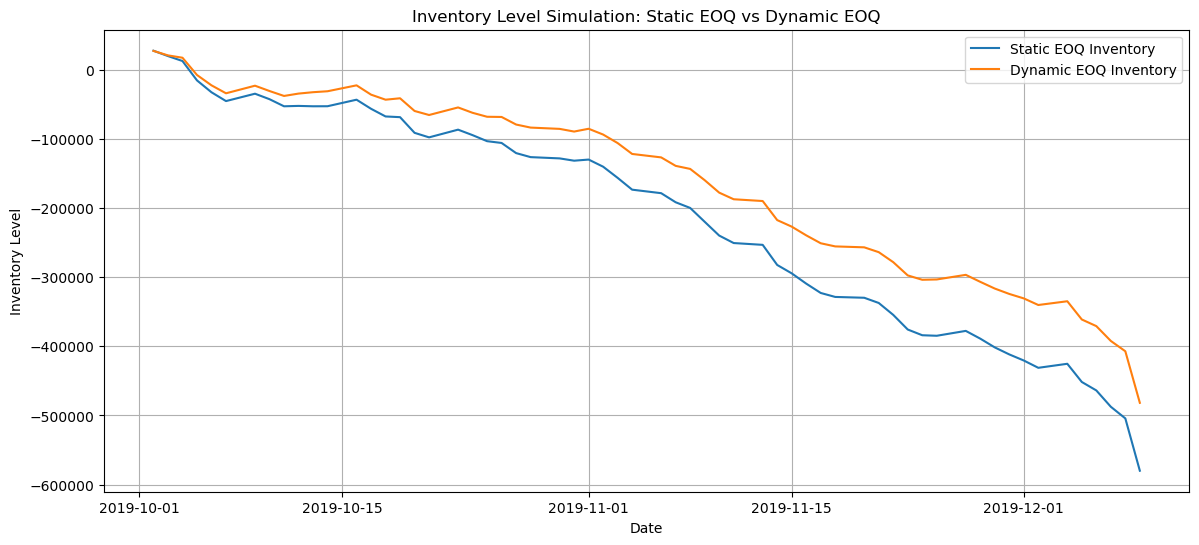

In [32]:
plt.figure(figsize=(14, 6))
plt.plot(simulation["date"], simulation["static_inventory"], label="Static EOQ Inventory")
plt.plot(simulation["date"], simulation["dynamic_inventory"], label="Dynamic EOQ Inventory")
plt.title("Inventory Level Simulation: Static EOQ vs Dynamic EOQ")
plt.xlabel("Date")
plt.ylabel("Inventory Level")
plt.legend()
plt.grid(True)
plt.show()

### Simulation Interpretation

The simulation investigates inventory dynamics under a pair of static and adaptive EOQ models.

The static EOQ policy has a single constant order quantity and the adaptive EOQ policy changes the order quantities according to the demand forecasts.
This enables the adaptive approach to react to variations in demand, resulting in a less restrictive inventory policy.

The findings can be considered as a simplified analytical exercise, not as a complete operational inventory system.

## 16. Business Impact
The approach we present can enable firms to enhance their inventory management by integrating demand prediction and inventory decision making.

Possible benefits to the enterprise are:

- better alignment between stock levels and expected demand,
- improved response to seasonal and calendar-based demand changes,
- reduced risk of stockouts,
- reduced risk of overstock,
- more data-driven ordering decisions.

This project demonstrates how traditional business models such as EOQ can be enhanced with data science methods.

## 17. Limitations

This project has several limitations that should be taken into account when interpreting the results:

1. **Historical data adjustment**  
   The original dataset covers the period 2010–2011. To match it with the available UK holiday data, the dates were shifted forward. This makes the analysis less realistic, as the calendar effects do not correspond to the original time period.

2. **Simplified cost assumptions**  
   Key parameters such as ordering cost, holding cost, lead time, and stockout cost are assumed rather than estimated from real data. These values are used mainly for demonstration purposes.

3. **Simplified inventory simulation**  
   The simulation does not consider real-world constraints such as supplier limitations, warehouse capacity, product shelf life, minimum order quantities, or variable lead times.

4. **Aggregated demand**  
   The analysis is based on total daily demand instead of modeling each product separately. This simplifies the problem but reduces the level of detail.

5. **Forecasting limitations**  
   The Random Forest model includes calendar, holiday, lag, and rolling-average features. While it slightly outperforms the naive baseline, the improvement is relatively small. This suggests that more advanced time-series techniques could lead to better results.

## 18. Conclusion


In this project, I explored how the EOQ model can be combined with demand forecasting to improve inventory planning.

The results show that demand is not stable over time and is influenced by factors such as seasonality and calendar effects. Because of this, using fixed assumptions for demand is not always realistic in practice.

Adding a forecasting step to the EOQ model makes the approach more flexible and closer to real-world behavior. It also shows how traditional inventory models can be extended using data analysis.

The Random Forest model performed slightly better than the naive baseline, with lower MAE and RMSE values. However, the improvement is small, which suggests that the model is only capturing part of the underlying patterns in the data.

Even so, the project builds a full pipeline — starting from raw data and ending with EOQ-based inventory decisions. This is useful because it shows how different steps connect in a real demand planning scenario.

There are several ways the model could be improved. For example, better time-based validation, lag features, and rolling statistics could help capture temporal patterns more effectively. It would also make sense to test models that are designed specifically for time-series data.

Overall, the project shows that machine learning can be useful in demand planning, but it does not automatically lead to better results. The small improvement over the baseline highlights the importance of proper feature engineering and validation.

At the same time, even simple forecasts can still be useful when combined with EOQ, since they can be translated into clear and actionable inventory decisions.

## References

- Online Retail Dataset: https://www.kaggle.com/datasets/carrie1/ecommerce-data?resource=download
- UK Holidays: https://www.kaggle.com/datasets/shivd24coder/uk-national-holidays-dataset
- EOQ model overview: https://en.wikipedia.org/wiki/Economic_order_quantity